<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Unsupervised K-Means Clustering of SY Resi Stock - property age, premise type, and gross area

## Notebook Overview

The notebook contains two main analytical passes: an initial exploratory pass followed by a cleaner, structured clustering workflow.

### 1. Exploratory Pass

The first section represents an exploratory stage of the analysis. The data are loaded and undergo initial cleaning, including missing-value handling, type conversion, and manual min-max normalization of the clustering features. The clustering features are **property age, premise type, and gross area**. `Domestic outbuilding` and `Unknown` premise types are excluded. Because `premise_type` is categorical, it is one-hot encoded before K-means is fitted.

A preliminary `KMeans` model with `n_clusters=10` is fitted to explore the structure of the dataset. The resulting clusters are visualized using 2D plots because premise type is categorical. An elbow curve is then generated by evaluating cluster counts from 1 to 20, followed by an exploratory model using `k=2`.

### 2. Structured Clustering Pass

The second section provides the main, cleaner analytical workflow:

1. **Prepare the data** — select property age, premise type, and gross area; remove `Domestic outbuilding` and `Unknown`; convert the numerical features to numeric values; and remove observations with missing required values.
2. **Encode and normalize the features** — one-hot encode `premise_type` and apply `MinMaxScaler` to the numerical features.
3. **Inspect feature distributions** — examine numerical feature distributions and premise-type frequencies.
4. **Evaluate different numbers of clusters** — fit K-means models for `k = 2–9` and calculate inertia, silhouette score, Calinski-Harabasz score, and Davies-Bouldin score. Due to the large dataset size, computationally expensive validation metrics are calculated using a representative sample.
5. **Visualize model selection** — generate elbow and silhouette-score plots.
6. **Select the final number of clusters** — use the clustering metrics as supporting evidence while selecting `k=2` for the final analysis.
7. **Fit the final K-means model** — apply K-means with two clusters to the complete encoded and normalized feature matrix and assign each property a cluster label.
8. **Profile and visualize the clusters** — report cluster sizes and percentages, calculate numerical summary statistics, examine premise-type composition by cluster, and visualize the clusters.
9. **Evaluate the final clustering** — calculate the final silhouette score using a representative sample and produce a summary table of the main clustering results.

### Overall Purpose

The structured section provides the main reproducible workflow for identifying residential building groups based on **property age, premise type, and gross area**. The categorical `premise_type` feature is represented using one-hot encoding, with `Domestic outbuilding` and `Unknown` excluded before clustering.


### Potential for real-world application

This notebook demonstrates an end-to-end K-means clustering workflow applied to residential building stock data for South Yorkshire. It is useful for:

- **Building stock segmentation** — grouping properties by age, premise type, and floor area to identify natural categories within a housing dataset, without relying on predefined labels.
- **Retrofit and energy-policy planning** — property age and size are strong proxies for construction standards and heating demand, making this type of clustering a common first step in identifying candidate groups for energy-efficiency retrofit programmes.
- **Reference workflow for K-means clustering** — the notebook walks through the core stages of a clustering pipeline: feature engineering (encoding categorical fields, imputing missing values), normalization, model fitting, the elbow method for selecting the number of clusters, and 3D visualization of results, making it a useful reference or starting point for similar clustering tasks.

> **Note:** The notebook is exploratory in nature and includes some leftover code, unused imports, and inconsistent handling of normalized vs. unnormalized features across cells. It would benefit from cleanup and the addition of quantitative cluster-validity metrics (e.g. silhouette score) before being used as a production reference.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import pylab as pl
pd.options.mode.copy_on_write = True
pd.set_option('future.no_silent_downcasting', True)

In [2]:
df=pd.read_csv('CSV_UKBe16_Resi_SouthYorkshire-clean.csv')

print (df.head())

  premise_age   premise_type  premise_floor_count  \
0   Post 1999  Semi-detached                  2.0   
1   1960-1979       Detached                  1.0   
2   1990-1999       Detached                  1.0   
3   1960-1979       Detached                  1.0   
4   1990-1999       Detached                  1.0   

                         bungalow  height  building_area  gross_area  
0                  Not a bungalow    10.2          245.2       490.4  
1      Bungalow (high confidence)     6.3          194.7       194.7  
2  Bungalow (moderate confidence)     7.1          128.1       128.1  
3  Bungalow (moderate confidence)     6.8          107.0       107.0  
4  Bungalow (moderate confidence)     4.9           98.7        98.7  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Set plot design
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ---------------------------------------------------------
# Step 1: Load Dataset
# ---------------------------------------------------------

# Use the same import

# ---------------------------------------------------------
# Step 2: Numerical Conversion for 'premise_age' & 'premise_type'
# ---------------------------------------------------------

# A. Convert 'premise_age' to numerical representative mid-point years
age_band_to_year = {
    'Pre 1919': 1900,
    '1919-1944': 1931,
    '1945-1959': 1952,
    '1960-1979': 1970,
    '1980-1989': 1985,
    '1990-1999': 1995,
    'Post 1999': 2010
}

# Map age strings to numeric year; calculate property age in years (relative to 2026)
df['premise_age_numeric'] = df['premise_age'].map(age_band_to_year)
# Fallback for unmapped or missing values via median imputation downstream
CURRENT_YEAR = 2026
df['property_age_years'] = CURRENT_YEAR - df['premise_age_numeric']

# Exclude premise types that are not to be used in the clustering analysis
excluded_premise_types = ['Domestic outbuilding', 'Unknown']
df = df.loc[~df['premise_type'].isin(excluded_premise_types)].copy()

# B. Convert 'bungalow' flag to numerical confidence scale
bungalow_map = {
    'Not a bungalow': 0.0,
    'Bungalow (moderate confidence)': 0.5,
    'Bungalow (high confidence)': 1.0
}
df['bungalow_numeric'] = df['bungalow'].map(bungalow_map)

# C. Specify feature groups
num_cols = ['property_age_years', 'height', 'building_area', 'gross_area', 'bungalow_numeric']
cat_cols = ['premise_type']

# ---------------------------------------------------------
# Step 3: Feature Engineering Pipeline (Encoding + Imputation + Scaling)
# ---------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Fit and transform dataset into a fully numerical feature matrix
X_processed = preprocessor.fit_transform(df)

# Retrieve feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols

X_df = pd.DataFrame(X_processed, columns=all_feature_names)

print(f"Processed Feature Matrix Shape: {X_processed.shape}")

Processed Feature Matrix Shape: (494501, 13)


In [4]:
# Keep the original cleaned dataframe `df` for the clustering workflow.
# `X_df` contains the earlier encoded feature matrix and is retained separately.
X_df.head()

,property_age_years,height,building_area,gross_area,bungalow_numeric,premise_type_Enclosed end-terrace,premise_type_Enclosed mid-terrace,premise_type_End-terrace,premise_type_Flat,premise_type_Maisonette,premise_type_Mid-terrace,premise_type_Semi-detached,premise_type_Terrace
0,-2.229073,1.182148,-0.002364,1.516609,-0.269364,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.463244,-1.255679,-0.166137,0.185444,3.803807,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.566887,-0.755612,-0.382122,-0.114372,1.767221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.463244,-0.943137,-0.450550,-0.209359,1.767221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.566887,-2.130797,-0.477467,-0.246724,1.767221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.head(2)

,premise_age,premise_type,premise_floor_count,bungalow,height,building_area,gross_area,premise_age_numeric,property_age_years,bungalow_numeric
0,Post 1999,Semi-detached,2.0,Not a bungalow,10.2,245.2,490.4,2010.0,16.0,0.0
1,1960-1979,Detached,1.0,Bungalow (high confidence),6.3,194.7,194.7,1970.0,56.0,1.0


In [6]:
# Keep the clustering variables together before encoding.
# `premise_type` is categorical, so it will be one-hot encoded below.
sub_df = df[['property_age_years', 'premise_type', 'gross_area']].copy()

# Exclude the two premise types requested by the analysis.
sub_df = sub_df.loc[
    ~sub_df['premise_type'].isin(['Domestic outbuilding', 'Unknown'])
].copy()

print(type(sub_df))
print(sub_df.head())

<class 'pandas.core.frame.DataFrame'>
   property_age_years   premise_type  gross_area
0                16.0  Semi-detached       490.4
1                56.0       Detached       194.7
2                31.0       Detached       128.1
3                56.0       Detached       107.0
4                31.0       Detached        98.7


In [7]:
print(type(sub_df))
print(sub_df.head())

<class 'pandas.core.frame.DataFrame'>
   property_age_years   premise_type  gross_area
0                16.0  Semi-detached       490.4
1                56.0       Detached       194.7
2                31.0       Detached       128.1
3                56.0       Detached       107.0
4                31.0       Detached        98.7


In [8]:
# Clean the categorical feature and numerical features.
sub_df.loc[:, 'premise_type'] = sub_df['premise_type'].fillna('Unknown')
sub_df.loc[:, 'property_age_years'] = pd.to_numeric(
    sub_df['property_age_years'], errors='coerce'
)
sub_df.loc[:, 'gross_area'] = pd.to_numeric(
    sub_df['gross_area'], errors='coerce'
)

# Remove rows that still lack one of the clustering variables.
sub_df = sub_df.dropna(
    subset=['property_age_years', 'premise_type', 'gross_area']
).copy()

print(sub_df['premise_type'].value_counts())


premise_type
Semi-detached           216427
Detached                104569
Mid-terrace              34898
End-terrace              26563
Terrace                  18195
Flat                      6896
Maisonette                1491
Enclosed end-terrace       139
Enclosed mid-terrace        24
Name: count, dtype: int64


In [9]:
# One-hot encode premise_type so that the categorical feature can be used by K-means.
premise_type_dummies = pd.get_dummies(
    sub_df['premise_type'],
    prefix='premise_type',
    dtype=float
)

sub_df_model = pd.concat(
    [
        sub_df[['property_age_years', 'gross_area']].copy(),
        premise_type_dummies
    ],
    axis=1
)

sub_df_model.head()

,property_age_years,gross_area,premise_type_Detached,premise_type_Enclosed end-terrace,premise_type_Enclosed mid-terrace,premise_type_End-terrace,premise_type_Flat,premise_type_Maisonette,premise_type_Mid-terrace,premise_type_Semi-detached,premise_type_Terrace
0,16.0,490.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,56.0,194.7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,31.0,128.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,56.0,107.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,31.0,98.7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
from sklearn.cluster import KMeans

In [11]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(sub_df_model)
predictions = km.predict(sub_df_model)
labels = km.labels_

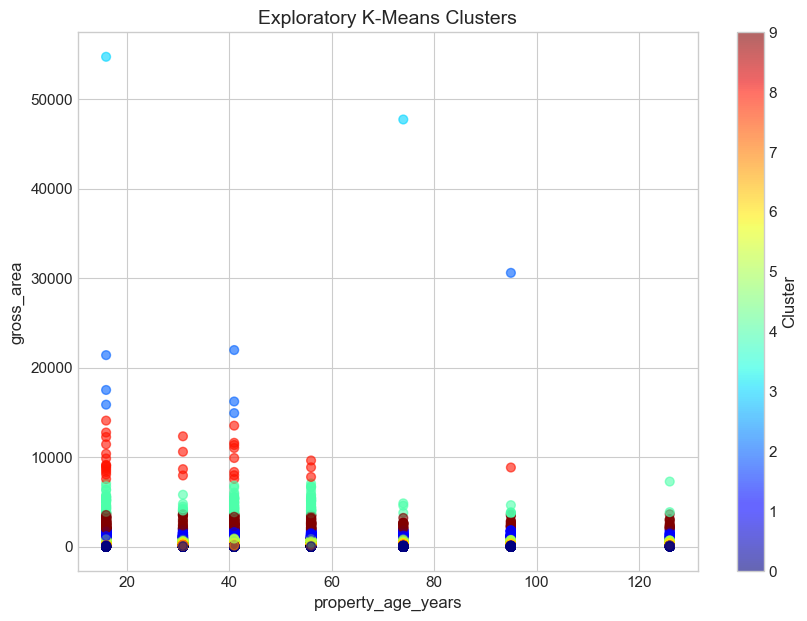

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    sub_df['property_age_years'],
    sub_df['gross_area'],
    c=predictions,
    s=40,
    cmap='jet',
    alpha=0.6
)

ax.set_xlabel('property_age_years')
ax.set_ylabel('gross_area')
ax.set_title('Exploratory K-Means Clusters')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

In [13]:
# Normalize the two numerical features.
for col in ['property_age_years', 'gross_area']:
    denominator = sub_df_model[col].max() - sub_df_model[col].min()
    sub_df_model.loc[:, col] = (
        (sub_df_model[col] - sub_df_model[col].min()) / denominator
        if denominator != 0 else 0.0
    )

In [14]:
# The categorical variables are already represented as 0/1 indicators.
# Keep the one-hot encoded premise_type columns unchanged.
sub_df_model.head()

,property_age_years,gross_area,premise_type_Detached,premise_type_Enclosed end-terrace,premise_type_Enclosed mid-terrace,premise_type_End-terrace,premise_type_Flat,premise_type_Maisonette,premise_type_Mid-terrace,premise_type_Semi-detached,premise_type_Terrace
0,0.000000,0.008774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.363636,0.003371,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.136364,0.002154,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.363636,0.001769,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.136364,0.001617,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
sub_df_cleaned = sub_df_model.dropna().copy()

km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(sub_df_cleaned)
predictions = km.predict(sub_df_cleaned)
labels = km.labels_

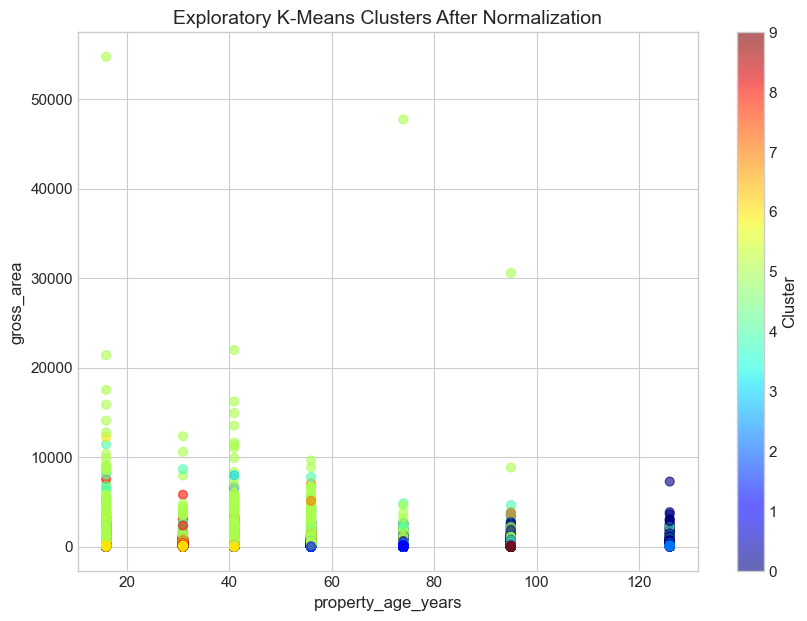

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    sub_df.loc[sub_df_cleaned.index, 'property_age_years'],
    sub_df.loc[sub_df_cleaned.index, 'gross_area'],
    c=predictions,
    s=40,
    cmap='jet',
    alpha=0.6
)

ax.set_xlabel('property_age_years')
ax.set_ylabel('gross_area')
ax.set_title('Exploratory K-Means Clusters After Normalization')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

In [17]:
# Initialize the list for KMeans models
kmeans = []

# Create a range of cluster counts
N = range(1, 20)

for i in N:
    kmeans.append(KMeans(n_clusters=i, random_state=42,n_init=10))


In [18]:
score = []
sub_df_cleaned = sub_df_model.dropna()

for i in range(len(kmeans)):
    score.append(kmeans[i].fit(sub_df_cleaned).score(sub_df_cleaned))

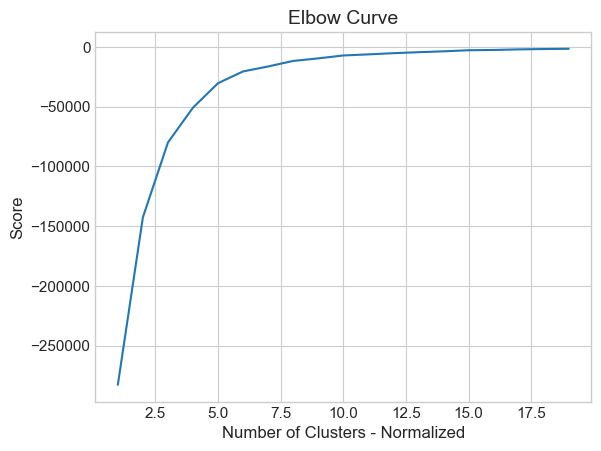

In [19]:
pl.plot(N,score)
pl.xlabel('Number of Clusters - Normalized')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [20]:
sub_df_cleaned = sub_df_model.dropna().copy()

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(sub_df_cleaned)
y = km.predict(sub_df_cleaned)
labels_norm = km.labels_

sub_df_cleaned.loc[:, 'Clusters_norm'] = y

print(sub_df_cleaned.head())

   property_age_years  gross_area  premise_type_Detached  \
0            0.000000    0.008774                    0.0   
1            0.363636    0.003371                    1.0   
2            0.136364    0.002154                    1.0   
3            0.363636    0.001769                    1.0   
4            0.136364    0.001617                    1.0   

   premise_type_Enclosed end-terrace  premise_type_Enclosed mid-terrace  \
0                                0.0                                0.0   
1                                0.0                                0.0   
2                                0.0                                0.0   
3                                0.0                                0.0   
4                                0.0                                0.0   

   premise_type_End-terrace  premise_type_Flat  premise_type_Maisonette  \
0                       0.0                0.0                      0.0   
1                       0.0           

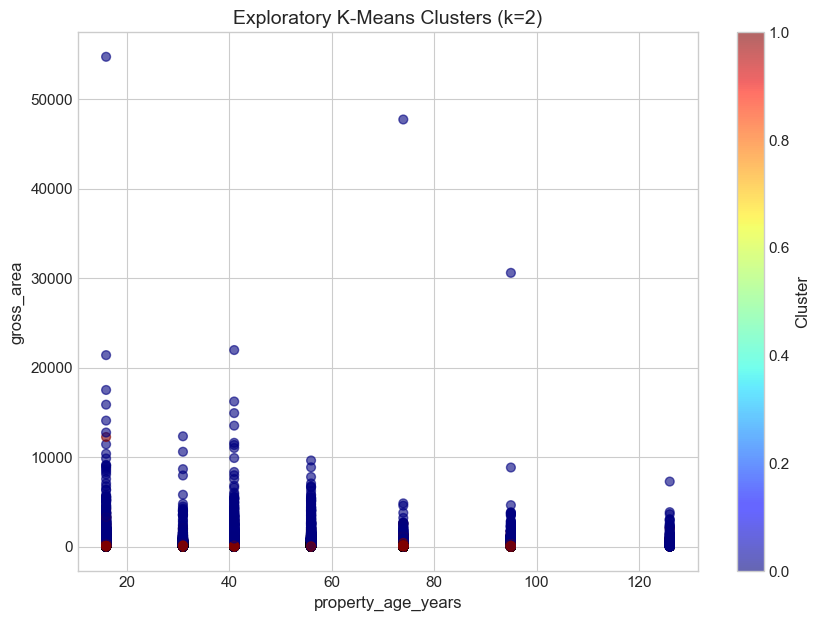

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    sub_df.loc[sub_df_cleaned.index, 'property_age_years'],
    sub_df.loc[sub_df_cleaned.index, 'gross_area'],
    c=sub_df_cleaned['Clusters_norm'],
    s=40,
    cmap='jet',
    alpha=0.6
)

ax.set_xlabel('property_age_years')
ax.set_ylabel('gross_area')
ax.set_title('Exploratory K-Means Clusters (k=2)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

# Before vs After Clustering

1. Feature distributions before clustering
2. Feature encoding and normalization
3. Choosing the number of clusters
   - Elbow method
   - Silhouette score
4. Final K-means model
5. Cluster sizes
6. Cluster profiles
7. Feature distributions by cluster
8. PCA visualization before clustering
9. PCA visualization after clustering
10. Cluster validity metrics
11. Interpretation

## 1. Prepare the clustering data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Features used for clustering
features = [
    "property_age_years",
    "premise_type",
    "gross_area"
]

numeric_features = [
    "property_age_years",
    "gross_area"
]

categorical_features = [
    "premise_type"
]

# Keep only required columns.
cluster_df = df[features].copy()

# Exclude premise types requested by the analysis.
cluster_df = cluster_df.loc[
    ~cluster_df["premise_type"].isin(["Domestic outbuilding", "Unknown"])
].copy()

# Convert numerical features to numeric.
for col in numeric_features:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

# Remove observations missing required clustering values.
cluster_df = cluster_df.dropna(
    subset=features
).copy()

print(f"Number of properties: {len(cluster_df):,}")
print("\nPremise types:")
print(cluster_df["premise_type"].value_counts())
cluster_df.head()

Number of properties: 409,202

Premise types:
premise_type
Semi-detached           216427
Detached                104569
Mid-terrace              34898
End-terrace              26563
Terrace                  18195
Flat                      6896
Maisonette                1491
Enclosed end-terrace       139
Enclosed mid-terrace        24
Name: count, dtype: int64


,property_age_years,premise_type,gross_area
0,16.0,Semi-detached,490.4
1,56.0,Detached,194.7
2,31.0,Detached,128.1
3,56.0,Detached,107.0
4,31.0,Detached,98.7


## 2. Before clustering: inspect feature distributions

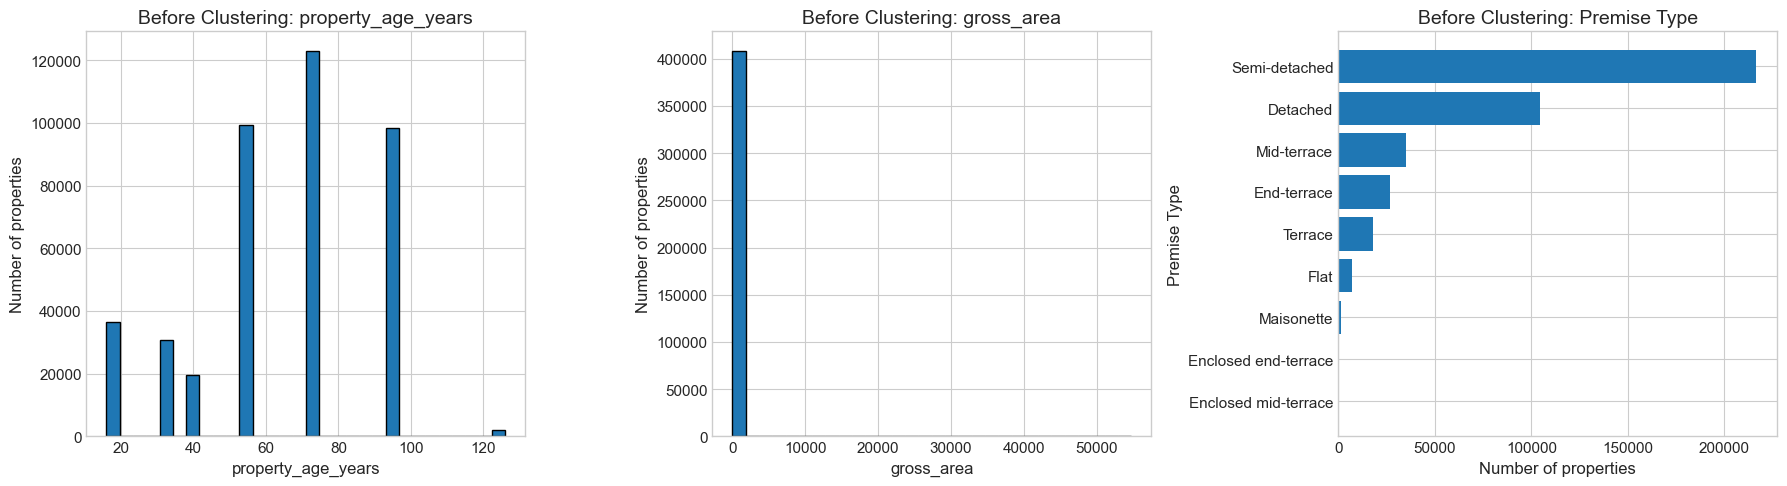

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes[:2], numeric_features):
    ax.hist(cluster_df[feature], bins=30, edgecolor="black")
    ax.set_title(f"Before Clustering: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of properties")

premise_counts = cluster_df["premise_type"].value_counts().sort_values()
axes[2].barh(premise_counts.index, premise_counts.values)
axes[2].set_title("Before Clustering: Premise Type")
axes[2].set_xlabel("Number of properties")
axes[2].set_ylabel("Premise Type")

plt.tight_layout()
plt.show()

In [24]:
cluster_df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
property_age_years,409202.0,64.928766,24.614906,16.0,56.0,74.0,74.0,126.0
gross_area,409202.0,156.441651,228.489219,10.2,99.0,122.0,167.8,54737.2


## 3. Normalize the features

In [25]:
# Normalize numerical features and one-hot encode the categorical premise_type feature.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_scaled = preprocessor.fit_transform(cluster_df[features])

encoded_premise_cols = list(
    preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

model_feature_names = numeric_features + encoded_premise_cols

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=model_feature_names,
    index=cluster_df.index
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
property_age_years,409202.0,0.444807,0.223772,0.0,0.363636,0.527273,0.527273,1.0
gross_area,409202.0,0.002672,0.004175,0.0,0.001623,0.002043,0.002880,1.0
premise_type_Detached,409202.0,0.255544,0.436167,0.0,0.000000,0.000000,1.000000,1.0
premise_type_Enclosed end-terrace,409202.0,0.000340,0.018427,0.0,0.000000,0.000000,0.000000,1.0
premise_type_Enclosed mid-terrace,409202.0,0.000059,0.007658,0.0,0.000000,0.000000,0.000000,1.0
premise_type_End-terrace,409202.0,0.064914,0.246375,0.0,0.000000,0.000000,0.000000,1.0
premise_type_Flat,409202.0,0.016852,0.128718,0.0,0.000000,0.000000,0.000000,1.0
premise_type_Maisonette,409202.0,0.003644,0.060253,0.0,0.000000,0.000000,0.000000,1.0
premise_type_Mid-terrace,409202.0,0.085283,0.279303,0.0,0.000000,0.000000,0.000000,1.0
premise_type_Semi-detached,409202.0,0.528900,0.499165,0.0,0.000000,1.000000,1.000000,1.0


## 4. Run K-means for different values of k

In [26]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

k_values = range(2, 10)

inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

# Sample for expensive validation metrics
sample_size = min(10000, len(X_scaled))

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

for k in k_values:

    print(f"Running k={k}...")

    # Fit K-means on the complete filtered dataset
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # Inertia from the complete dataset
    inertias.append(kmeans.inertia_)

    # Use sample for expensive validation metrics
    sample_labels = labels[sample_indices]

    silhouette_scores.append(
        silhouette_score(
            X_sample,
            sample_labels
        )
    )

    calinski_scores.append(
        calinski_harabasz_score(
            X_sample,
            sample_labels
        )
    )

    davies_scores.append(
        davies_bouldin_score(
            X_sample,
            sample_labels
        )

    )

    print(f"  Inertia: {kmeans.inertia_:,.0f}")
    print(f"  Silhouette: {silhouette_scores[-1]:.3f}")

Running k=2...
  Inertia: 142,701
  Silhouette: 0.594
Running k=3...
  Inertia: 80,037
  Silhouette: 0.718
Running k=4...
  Inertia: 50,840
  Silhouette: 0.778
Running k=5...
  Inertia: 30,352
  Silhouette: 0.820
Running k=6...
  Inertia: 20,529
  Silhouette: 0.839
Running k=7...
  Inertia: 16,361
  Silhouette: 0.719
Running k=8...
  Inertia: 11,736
  Silhouette: 0.697
Running k=9...
  Inertia: 9,593
  Silhouette: 0.747


## 5. Plot the elbow and silhouette scores

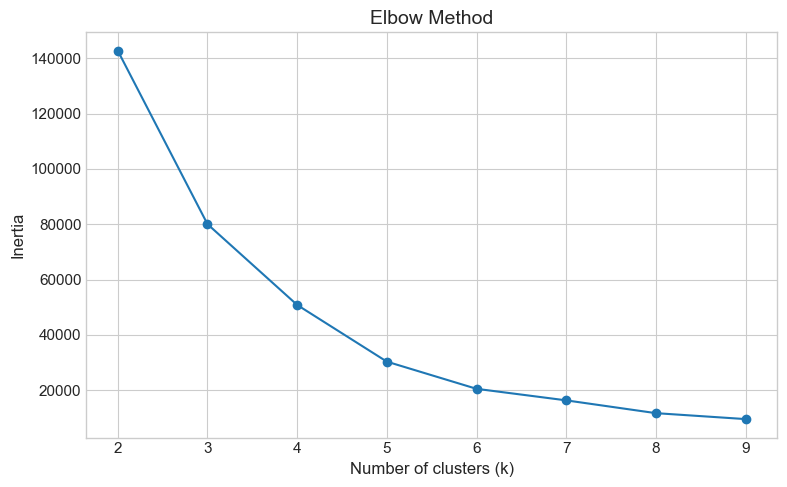

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values, inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method")

ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

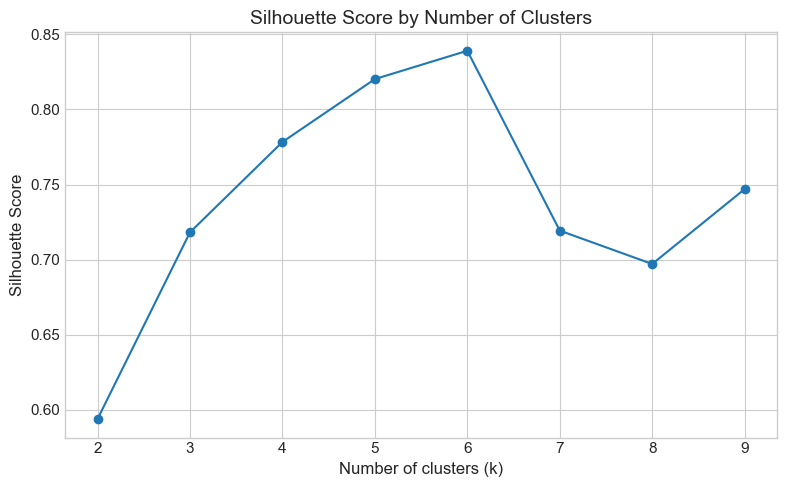

In [28]:
# And the silhouette score:

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values, silhouette_scores, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by Number of Clusters")

ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

## 6. Compare clustering metrics

In [29]:
metrics_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "calinski_harabasz_score": calinski_scores,
    "davies_bouldin_score": davies_scores
})

metrics_df

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,142700.566596,0.593944,9855.917153,0.798724
1,3,80036.750601,0.718202,12754.670035,0.902280
2,4,50839.989252,0.778300,15359.139361,0.817576
3,5,30352.359468,0.820157,21075.400581,0.677817
4,6,20529.342536,0.839013,25556.731091,0.530052
5,7,16360.814408,0.719346,26968.900597,0.514876
6,8,11736.269624,0.697141,32763.554605,0.478352
7,9,9593.311109,0.746951,35108.846872,0.503530


In [30]:
# identify the best silhouette score with:

best_k = metrics_df.loc[
    metrics_df["silhouette_score"].idxmax(),
    "k"
]

print(f"Best k according to silhouette score: {best_k}")

Best k according to silhouette score: 6


## 7. Fit the final model

In [31]:
final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

cluster_df["Clusters_norm"] = cluster_labels

In [32]:
# Check cluster sizes:

cluster_counts = (
    cluster_df["Clusters_norm"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Clusters_norm
0    192775
1    216427
Name: count, dtype: int64


## 8. Compare cluster sizes

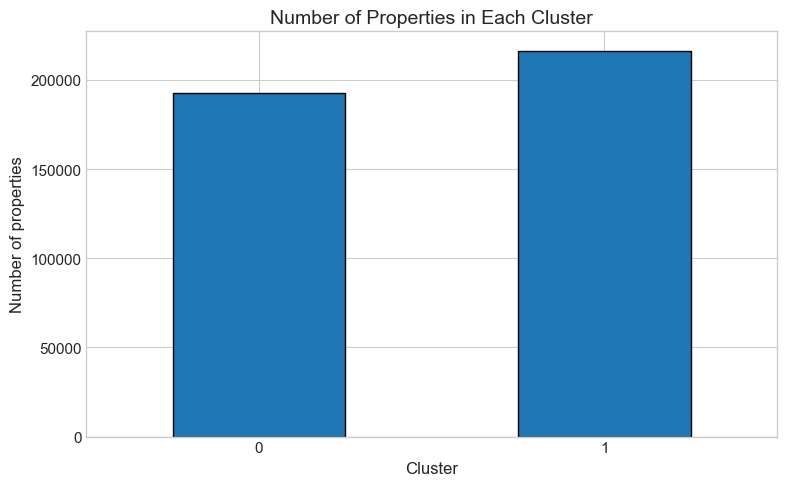

In [33]:
cluster_counts.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.xlabel("Cluster")
plt.ylabel("Number of properties")
plt.title("Number of Properties in Each Cluster")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# calculate percentages:

cluster_percentages = (
    cluster_df["Clusters_norm"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

print(cluster_percentages)

Clusters_norm
0    47.1
1    52.9
Name: proportion, dtype: float64


## 9. Create cluster profiles

In [36]:
# Cluster profiles for numerical features
cluster_profile_numeric = (
    cluster_df
    .assign(Clusters_norm=cluster_labels)
    .groupby("Clusters_norm")[numeric_features]
    .agg(["count", "mean", "median", "std"])
)

cluster_profile_numeric

property_age_years                              gross_area  \
                           count       mean median        std      count   
Clusters_norm                                                              
0                         192775  56.995549   56.0  25.855082     192775   
1                         216427  71.995010   74.0  21.074978     216427   

                                              
                     mean median         std  
Clusters_norm                                 
0              192.055011  145.0  321.334586  
1              124.720260  111.8   67.836775

In [37]:
# Premise-type composition within each cluster
cluster_profile_premise = (
    pd.crosstab(
        cluster_df["premise_type"],
        cluster_labels,
        normalize="columns"
    )
    .mul(100)
    .round(1)
)

cluster_profile_premise

col_0,0,1
premise_type,,
Detached,54.2,0.0
Enclosed end-terrace,0.1,0.0
Enclosed mid-terrace,0.0,0.0
End-terrace,13.8,0.0
Flat,3.6,0.0
Maisonette,0.8,0.0
Mid-terrace,18.1,0.0
Semi-detached,0.0,100.0
Terrace,9.4,0.0


In [38]:
cluster_profile_numeric = (
    cluster_df
    .groupby("Clusters_norm")[numeric_features]
    .agg(["count", "mean", "median", "std"])
)

cluster_profile_premise = (
    pd.crosstab(
        cluster_df["premise_type"],
        cluster_df["Clusters_norm"],
        normalize="columns"
    )
    .mul(100)
    .round(1)
)

In [39]:
# Numerical summary by cluster
cluster_summary = (
    cluster_df
    .assign(Cluster=cluster_labels)
    .groupby("Cluster")
    .agg(
        properties=("property_age_years", "size"),
        mean_age=("property_age_years", "mean"),
        median_age=("property_age_years", "median"),
        mean_area=("gross_area", "mean"),
        median_area=("gross_area", "median")
    )
    .round(2)
)

cluster_summary

,properties,mean_age,median_age,mean_area,median_area
Cluster,,,,,
0,192775,57.0,56.0,192.06,145.0
1,216427,72.0,74.0,124.72,111.8


## 10. After clustering: box plots

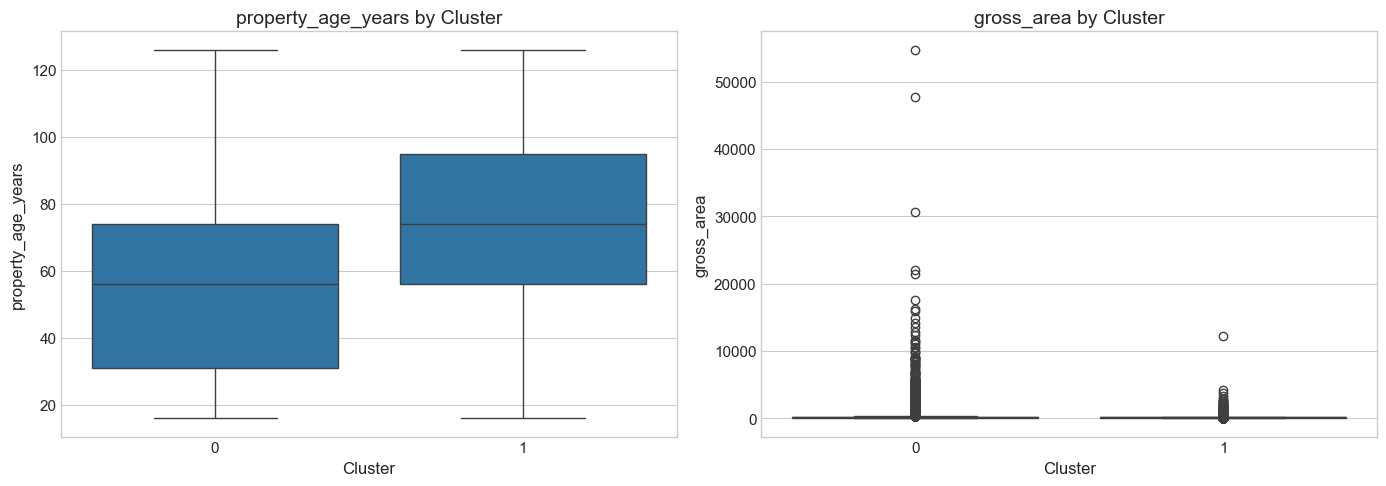

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(
        data=cluster_df.assign(Clusters_norm=cluster_labels),
        x="Clusters_norm",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 11. Compare distributions by cluster

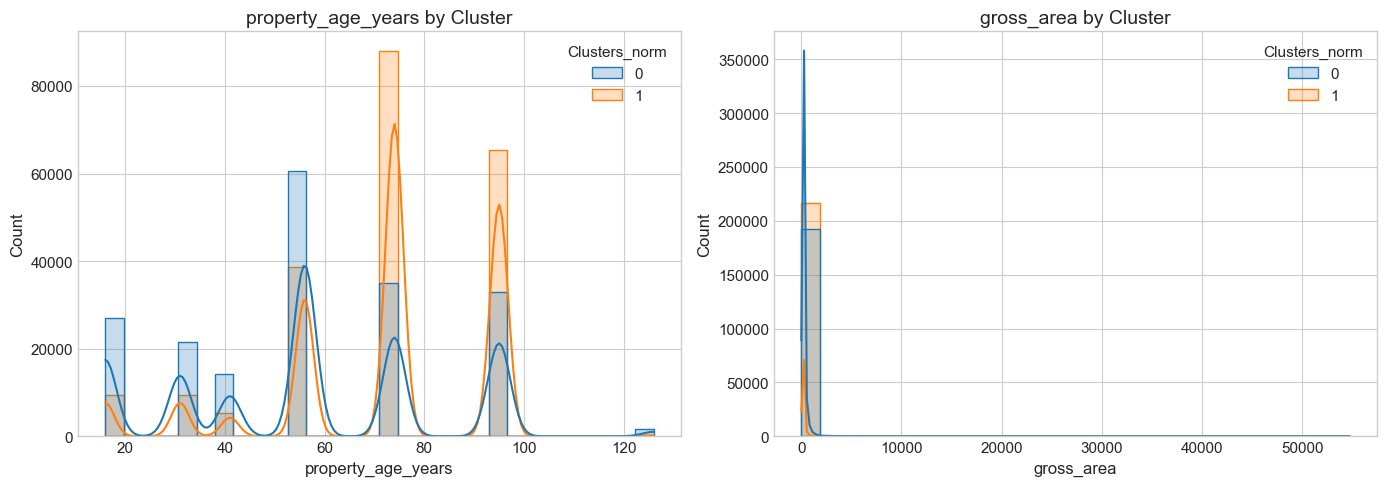

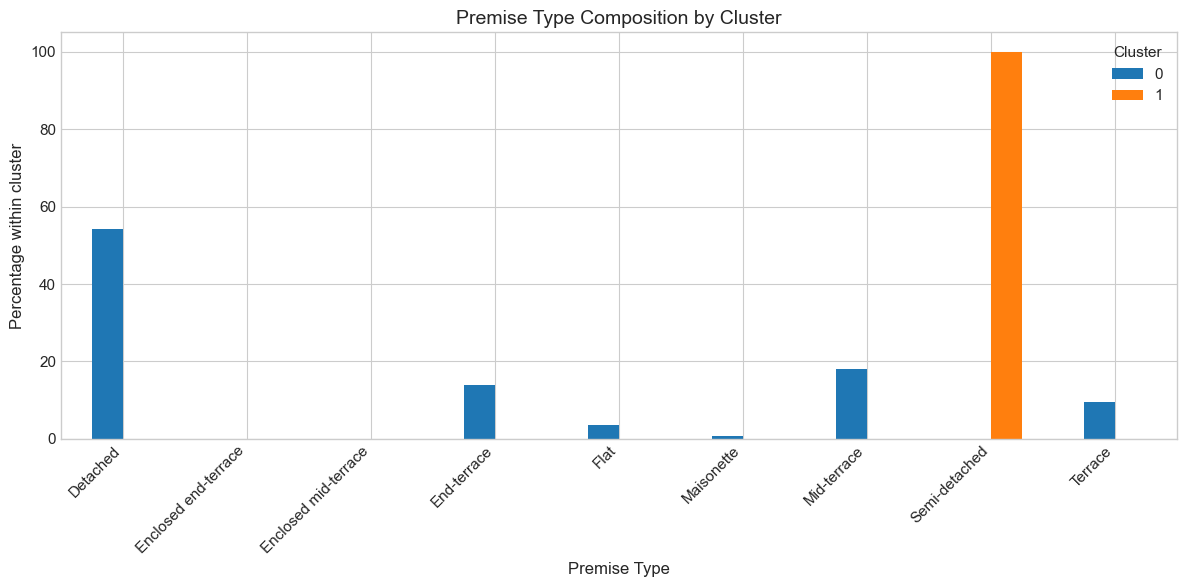

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, numeric_features):
    sns.histplot(
        data=cluster_df.assign(Clusters_norm=cluster_labels),
        x=feature,
        hue="Clusters_norm",
        bins=30,
        kde=True,
        element="step",
        ax=ax
    )
    ax.set_title(f"{feature} by Cluster")
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

# Premise-type composition by cluster
premise_cluster = pd.crosstab(
    cluster_df["premise_type"],
    cluster_labels,
    normalize="columns"
).mul(100).round(1)

premise_cluster.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.xlabel("Premise Type")
plt.ylabel("Percentage within cluster")
plt.title("Premise Type Composition by Cluster")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 12. 3D plot before clustering

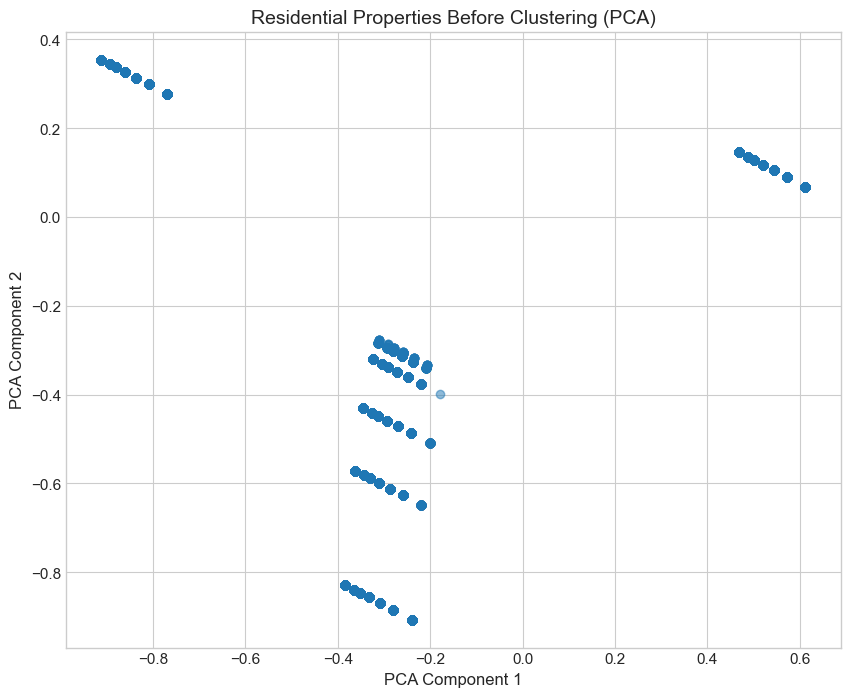

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("Residential Properties Before Clustering (PCA)")
plt.show()

## 13. 3D plot after clustering

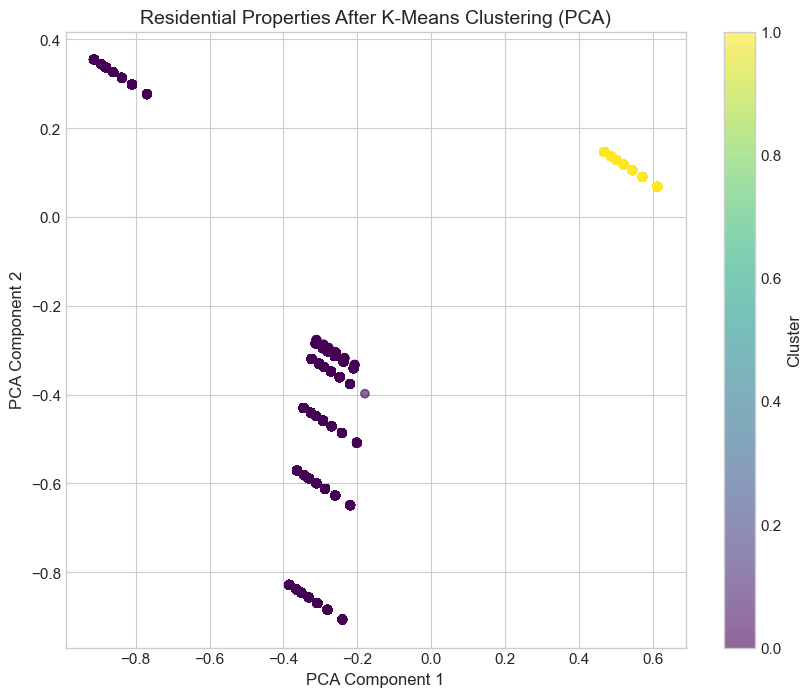

In [43]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_df["Clusters_norm"],
    cmap="viridis",
    alpha=0.6
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("Residential Properties After K-Means Clustering (PCA)")

plt.colorbar(
    scatter,
    ax=ax,
    label="Cluster"
)

plt.show()

## 14. Evaluate the final clustering

In [44]:
# ============================================
# 14. Fast evaluation of final clustering
# ============================================

from sklearn.metrics import silhouette_score

# Use a small reproducible sample
sample_size = min(5000, len(X_scaled))

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]
labels_sample = cluster_labels[sample_indices]

# Calculate silhouette score on the sample
final_silhouette = silhouette_score(
    X_sample,
    labels_sample
)

print("Final Clustering Evaluation")
print("----------------------------")
print(f"Total properties:   {len(X_scaled):,}")
print(f"Evaluation sample:  {sample_size:,}")
print(f"Number of clusters: {final_k}")
print(f"Silhouette score:   {final_silhouette:.3f}")

Final Clustering Evaluation
----------------------------
Total properties:   409,202
Evaluation sample:  5,000
Number of clusters: 2
Silhouette score:   0.597


## 15. Compare raw vs normalized K-means

In [45]:
# Compare the final clustered groups using the raw clustering variables.
comparison_df = cluster_df[
    ["property_age_years", "premise_type", "gross_area"]
].copy()

comparison_df["Cluster"] = cluster_labels

# Numerical summary statistics by cluster
cluster_comparison = (
    comparison_df
    .groupby("Cluster")
    .agg(
        Properties=("property_age_years", "size"),
        Mean_Age=("property_age_years", "mean"),
        Median_Age=("property_age_years", "median"),
        Mean_Area=("gross_area", "mean"),
        Median_Area=("gross_area", "median")
    )
    .round(2)
)

print("Numerical cluster comparison:")
display(cluster_comparison)

# Premise-type distribution within each cluster
premise_type_comparison = pd.crosstab(
    comparison_df["premise_type"],
    comparison_df["Cluster"],
    normalize="columns"
).mul(100).round(2)

print("\nPremise type percentage within each cluster:")
display(premise_type_comparison)

Numerical cluster comparison:


,Properties,Mean_Age,Median_Age,Mean_Area,Median_Area
Cluster,,,,,
0,192775,57.0,56.0,192.06,145.0
1,216427,72.0,74.0,124.72,111.8



Premise type percentage within each cluster:


Cluster,0,1
premise_type,,
Detached,54.24,0.0
Enclosed end-terrace,0.07,0.0
Enclosed mid-terrace,0.01,0.0
End-terrace,13.78,0.0
Flat,3.58,0.0
Maisonette,0.77,0.0
Mid-terrace,18.10,0.0
Semi-detached,0.00,100.0
Terrace,9.44,0.0


## 16. Final comparison table

In [46]:
# ============================================
# 16. Final clustering results
# ============================================

final_results = pd.DataFrame({
    "Metric": [
        "Total properties",
        "Number of clusters",
        "Validation sample",
        "Silhouette score"
    ],
    "Result": [
        f"{len(cluster_df):,}",
        final_k,
        f"{sample_size:,}",
        round(final_silhouette, 3)
    ]
})

final_results

,Metric,Result
0,Total properties,"409,202"
1,Number of clusters,2
2,Validation sample,"5,000"
3,Silhouette score,0.597


In [47]:
# Cluster size and percentage
cluster_sizes = (
    cluster_df["Clusters_norm"]
    .value_counts()
    .sort_index()
    .to_frame("Properties")
)

cluster_sizes["Percentage"] = (
    cluster_sizes["Properties"]
    / len(cluster_df)
    * 100
).round(2)

cluster_sizes

,Properties,Percentage
Clusters_norm,,
0,192775,47.11
1,216427,52.89
